# 03 · Synthetic control vs DiD

**Question:** if we build a custom control (a weighted mix of states that matches Texas before the launch), do we get better lift estimates than DiD?

**Answer:** the fit is much better (pre-period MAE **0.067** vs **~0.10** for simple averages), but the estimates are **not more accurate**: across 34 placebo states, median error is **3.3%** for SCM vs **2.9%** for DiD, and SCM wins in exactly **17 of 34**.

$$\text{synthetic Texas}_t = \sum_j w_j \cdot \text{State}_{j,t}, \quad w_j \ge 0,\ \sum_j w_j = 1 \qquad \text{SCM lift} = \frac{\text{actual}_{after}}{\text{synthetic}_{after}} - 1$$

**Data:** GA4 Google Merchandise Store public sample (BigQuery `ga4_obfuscated_sample_ecommerce`), aggregated to sessions per US state per day, 2020-11-01 to 2021-01-31. Lifts are **injected** into real data (semi-synthetic), so the true effect is always known. Analysis uses the 34 states with a median of at least 10 sessions/day; each series is indexed to its pre-period mean.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

df = pd.read_csv("data/ga4_state_daily.csv", parse_dates=["date"])
START = pd.Timestamp("2021-01-04")
WINDOW = pd.Timedelta(days=28)

wide = df.pivot(index="date", columns="state", values="sessions").fillna(0)
daily_median = df.groupby("state").sessions.median()
wide = wide[daily_median[daily_median >= 10].index]

pre  = wide.index < START                                   # 11/01 – 01/03 (64 days): used to FIT
post = (wide.index >= START) & (wide.index < START + WINDOW) # 01/04 – 01/31: used to MEASURE
indexed = wide / wide[pre].mean()
print(wide.shape)

(92, 34)


## Step 1 · Hand-built controls

Average of three large states:

['Illinois', 'New York', 'California'] → pre-period MAE: 0.102


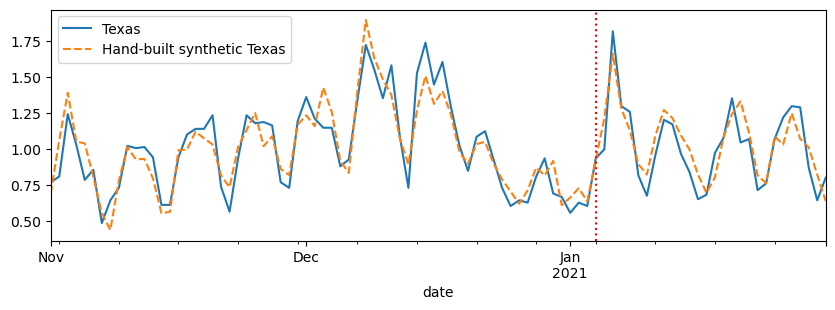

In [2]:
my_states = ["Illinois", "New York", "California"]

synthetic = indexed[my_states].mean(axis=1)
mae = (indexed["Texas"] - synthetic)[pre].abs().mean()
print(f"{my_states} → pre-period MAE: {mae:.3f}")

ax = indexed["Texas"].plot(figsize=(10, 3), label="Texas")
synthetic.plot(ax=ax, ls="--", label="Hand-built synthetic Texas")
ax.axvline(START, color="red", ls=":"); ax.legend(); plt.show()

Geographic neighbors:

In [3]:
for combo in [["Arizona"], ["Arizona", "Oklahoma", "Louisiana"]]:
    syn = indexed[combo].mean(axis=1)
    print(f"{combo} → pre-period MAE: {(indexed['Texas'] - syn)[pre].abs().mean():.3f}")

['Arizona'] → pre-period MAE: 0.206
['Arizona', 'Oklahoma', 'Louisiana'] → pre-period MAE: 0.164


Top 3 states by pre-period correlation with Texas (pre-period only, to avoid using campaign data):

state
California    0.908
New York      0.897
Virginia      0.877
Washington    0.855
Florida       0.853
Michigan      0.843
Name: Texas, dtype: float64
Top 3 by correlation: ['California', 'New York', 'Virginia'] → pre-period MAE: 0.099


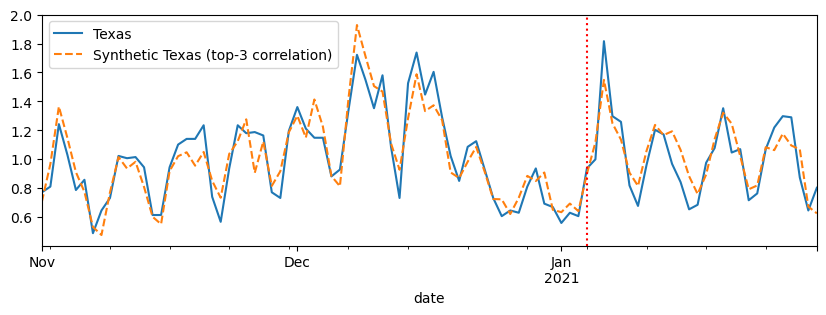

In [4]:
corr_with_tx = indexed[pre].corr()["Texas"]
print(corr_with_tx.drop("Texas").sort_values(ascending=False).head(6).round(3))

top3 = corr_with_tx.drop("Texas").nlargest(3).index.tolist()
synthetic_corr = indexed[top3].mean(axis=1)
mae_corr = (indexed["Texas"] - synthetic_corr)[pre].abs().mean()
print(f"Top 3 by correlation: {top3} → pre-period MAE: {mae_corr:.3f}")

ax = indexed["Texas"].plot(figsize=(10, 3), label="Texas")
synthetic_corr.plot(ax=ax, ls="--", label="Synthetic Texas (top-3 correlation)")
ax.axvline(START, color="red", ls=":"); ax.legend(); plt.show()

Top 3 states by individual MAE (high correlation doesn't guarantee small distance):

In [5]:
mae_by_state = indexed[pre].sub(indexed.loc[pre, "Texas"], axis=0).abs().mean()
top3_mae = mae_by_state.drop("Texas").nsmallest(3).index.tolist()
syn = indexed[top3_mae].mean(axis=1)
print(f"Top 3 by MAE: {top3_mae} → pre-period MAE: {(indexed['Texas'] - syn)[pre].abs().mean():.3f}")
print("Same states as correlation?", set(top3_mae) == set(top3))

# Why size beats geography: bigger states fit better
size = wide[pre].mean().drop("Texas")
print(f"Correlation between log(state size) and MAE vs Texas: {np.corrcoef(np.log(size), mae_by_state.drop('Texas'))[0, 1]:.2f}")

Top 3 by MAE: ['California', 'New York', 'Virginia'] → pre-period MAE: 0.099
Same states as correlation? True
Correlation between log(state size) and MAE vs Texas: -0.88


## Step 2 · Optimized weights

Minimize mean squared error between `X @ w` (donors) and `y` (Texas) over the pre-period, with 0 ≤ w ≤ 1 and Σw = 1, using `scipy.optimize.minimize` (SLSQP supports both constraints).

In [6]:
donors = [s for s in wide.columns if s != "Texas"]
X = indexed.loc[pre, donors].values
y = indexed.loc[pre, "Texas"].values

def loss(w):
    return np.mean((X @ w - y) ** 2)

k = len(donors)
res = minimize(loss, np.full(k, 1 / k), method="SLSQP",
               bounds=[(0, 1)] * k,                                         # each weight between 0 and 1
               constraints={"type": "eq", "fun": lambda w: w.sum() - 1})   # weights sum to 1
weights = pd.Series(res.x, index=donors).sort_values(ascending=False)

synthetic_opt = indexed[donors] @ weights[donors]
mae_opt = (indexed["Texas"] - synthetic_opt)[pre].abs().mean()
print(f"Optimized pre-period MAE: {mae_opt:.3f}")
print(f"States with weight > 0.01: {(weights > 0.01).sum()} of {k}")
print(f"California weight: {weights['California']:.3f}")
weights.head(8).round(3)

Optimized pre-period MAE: 0.067
States with weight > 0.01: 12 of 33
California weight: 0.000


Missouri          0.175
New York          0.157
Wisconsin         0.143
Utah              0.122
South Carolina    0.102
Tennessee         0.072
Oklahoma          0.055
Connecticut       0.046
dtype: float64

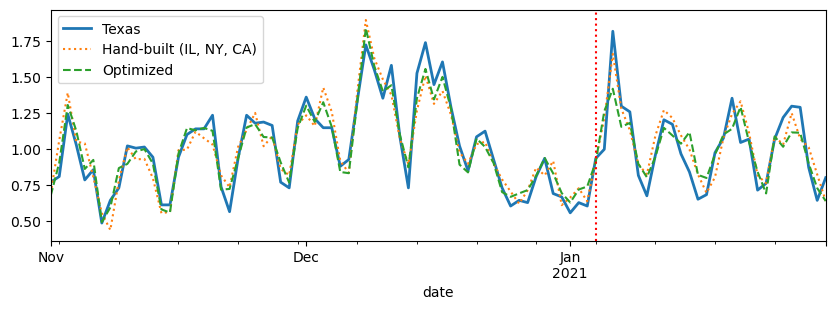

In [7]:
# Plot: hand-built vs optimized
ax = indexed["Texas"].plot(figsize=(10, 3), label="Texas", lw=2)
synthetic.plot(ax=ax, ls=":", label="Hand-built (IL, NY, CA)")
synthetic_opt.plot(ax=ax, ls="--", label="Optimized")
ax.axvline(START, color="red", ls=":"); ax.legend(); plt.show()

### Why California gets zero weight

It is the best *single* match, but it makes the *mix* worse:

In [8]:
print(f"Peak (pre-period max, indexed): Texas {indexed.loc[pre, 'Texas'].max():.2f} | "
      f"California {indexed.loc[pre, 'California'].max():.2f} | optimized mix {synthetic_opt[pre].max():.2f}")

# Force 30% California and re-optimize the rest
ca = donors.index("California")
res_ca = minimize(loss, np.full(k, 1 / k), method="SLSQP", bounds=[(0, 1)] * k,
                  constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1},
                               {"type": "eq", "fun": lambda w: w[ca] - 0.3}])
print(f"MSE: optimized {res.fun:.4f} | forced 30% California {res_ca.fun:.4f}")

Peak (pre-period max, indexed): Texas 1.74 | California 2.00 | optimized mix 1.84
MSE: optimized 0.0071 | forced 30% California 0.0081


### Robustness: adding a correlation term to the loss

In [9]:
def loss_with_corr(w):
    synthetic = X @ w
    correlation = np.corrcoef(y, synthetic)[0, 1]
    return np.mean((y - synthetic) ** 2) + (1 - correlation)

res_c = minimize(loss_with_corr, np.full(k, 1 / k), method="SLSQP", bounds=[(0, 1)] * k,
                 constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
for name, w in [("MSE only", res.x), ("MSE + (1 - corr)", res_c.x)]:
    s = X @ w
    top = pd.Series(w, index=donors).nlargest(3).round(3).to_dict()
    print(f"{name:18s} MAE {np.mean(np.abs(s - y)):.4f} | corr {np.corrcoef(y, s)[0, 1]:.3f} | top 3 {top}")

MSE only           MAE 0.0671 | corr 0.964 | top 3 {'Missouri': 0.175, 'New York': 0.157, 'Wisconsin': 0.143}
MSE + (1 - corr)   MAE 0.0677 | corr 0.964 | top 3 {'Wisconsin': 0.166, 'New York': 0.165, 'Missouri': 0.159}


## Step 3 · SCM lift for Texas

Weights are fit on the pre-period, frozen, and applied to the test window. Lift divides by the **counterfactual**; dividing by the actual result would give the *incremental share*, a different metric.

In [10]:
def scm_lift(data, treated):
    """data: wide table (date × state). treated: ONE state name."""
    idx = data / data[pre].mean()
    donors = [s for s in data.columns if s != treated]
    X, y = idx.loc[pre, donors].values, idx.loc[pre, treated].values
    k = len(donors)
    res = minimize(lambda w: np.mean((X @ w - y) ** 2), np.full(k, 1 / k), method="SLSQP",
                   bounds=[(0, 1)] * k, constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    synthetic = (idx[donors] @ res.x) * data.loc[pre, treated].mean()   # back to real session units
    actual_after    = data.loc[post, treated].sum()
    synthetic_after = synthetic[post].sum()
    return actual_after / synthetic_after - 1

wide_lift = wide.astype(float).copy()
wide_lift.loc[post, "Texas"] *= 1.10

print(f"Texas, no lift:   SCM = {scm_lift(wide, 'Texas'):.1%}   (DiD was -0.7%)")
print(f"Texas, +10% lift: SCM = {scm_lift(wide_lift, 'Texas'):.1%}   (DiD was 9.2%)")

Texas, no lift:   SCM = 0.7%   (DiD was -0.7%)
Texas, +10% lift: SCM = 10.8%   (DiD was 9.2%)


## Step 4 · Placebo test: SCM vs DiD on all 34 states (true effect = 0)

In [11]:
def did_lift(data, treated):
    before = data.index >= START - WINDOW
    T = data[treated]; C = data.drop(columns=treated).sum(axis=1)
    return (T[post].sum() / T[pre & before].sum()) / (C[post].sum() / C[pre & before].sum()) - 1

placebo = pd.DataFrame({s: {"scm": scm_lift(wide, s), "did": did_lift(wide, s)} for s in wide.columns}).T
print("Median |error|:", placebo.abs().median().round(3).to_dict())
print("SCM beats DiD in", (placebo.scm.abs() < placebo.did.abs()).sum(), "of", len(placebo), "states")
placebo.loc[["Texas", "Illinois", "Washington", "Pennsylvania"]].round(3)

Median |error|: {'scm': 0.033, 'did': 0.029}
SCM beats DiD in 17 of 34 states


,scm,did
Texas,0.007,-0.011
Illinois,0.034,0.047
Washington,0.053,0.061
Pennsylvania,0.011,0.053


## Findings

**Building the control (pre-period MAE, indexed scale)**

| Control | MAE |
|---|---|
| Arizona (neighbor) | 0.206 |
| Arizona, Oklahoma, Louisiana (neighbors) | 0.164 |
| Illinois, New York, California | 0.102 |
| Top 3 by correlation = top 3 by MAE (California, New York, Virginia) | 0.099 |
| **Optimized weights** (Missouri .18, New York .16, Wisconsin .14, Utah .12, South Carolina .10, …) | **0.067** |

- **Size beats geography.** Fit is driven by state size (corr −0.88), not location: this is an online store following national shopping patterns, and small states are noisy.
- **California gets weight 0.** Its December peak overshoots Texas (2.00 vs 1.74) and its weekly swing is too flat; forcing 30% California raises MSE from 0.0071 to 0.0081. Weights reflect usefulness **in combination**, not individual similarity. About 12 of 33 donors get meaningful weight.
- **A correlation term in the loss changes nothing** (MAE 0.0677 vs 0.0671): indexing plus sum-to-one weights already pin the level, so plain MSE is enough.

**Estimates**

| Test | Truth | DiD | SCM |
|---|---|---|---|
| Texas, no lift | 0% | −0.7% | +0.7% |
| Texas, +10% | 10% | 9.2% | 10.8% |
| Placebo, 34 states: median \|error\| | 0% | **2.9%** | **3.3%** |

- Better pre-period fit did **not** translate into better estimates. Fit is like *training* error; placebo error is like *test* error.
- Reasons: 33 weights on 64 noisy days overfit noise; the remaining error is state-specific noise in January that no control can predict; trends were already mostly parallel, so there was little bias for SCM to remove.
- On DiD's worst states (Illinois, Washington, Pennsylvania), SCM looks clearly better, but across all states it's a coin flip. Judging on hand-picked examples would be cherry-picking.

## Implications

- Choose the estimator by **placebo error across all units**, not by pre-period fit or sophistication.
- SCM earns its keep when the treated unit is unlike any simple control, trends aren't parallel, or the pre-period is long and stable. GeoLift's augmented SCM is compared in [08](08_meta_geolift_comparison.ipynb).